🚀 Firing up the Batch Ensemble Pipeline on: mps
📂 Scanning Test Directory for Images...

🔍 Processing a batch of 5 Medical Scans...
⏳ Loading CNN Model...
⏳ Loading VQA Model...


Loading weights: 100%|██████████| 787/787 [00:00<00:00, 13260.74it/s]


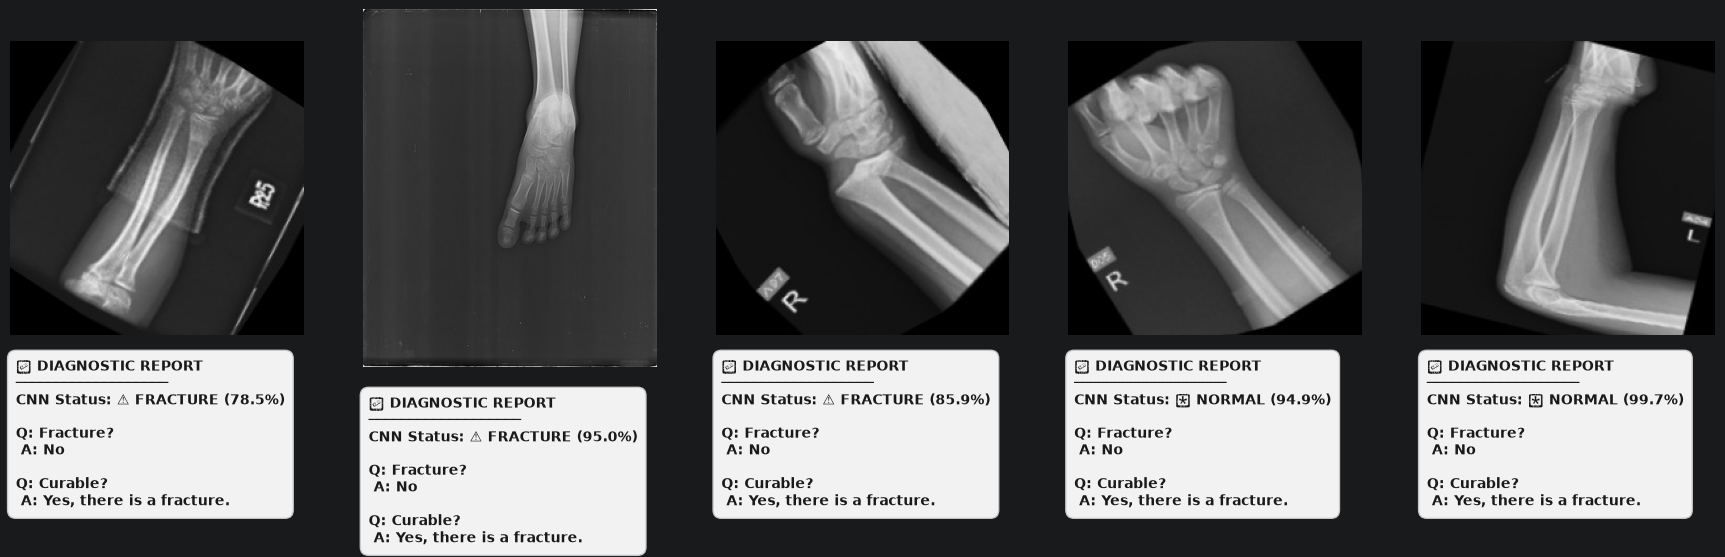

💾 Batch report successfully saved to: /Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/batch_diagnostic_report.png


<Figure size 640x480 with 0 Axes>

In [6]:
import os
import random
import torch
from PIL import Image, ImageFile
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.models as models
from transformers import BlipProcessor, BlipForQuestionAnswering

# Prevents crashes if an image header is slightly corrupted
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Hardware Optimization for Mac (Apple Silicon / MPS)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"🚀 Firing up the Batch Ensemble Pipeline on: {device}")

# Define absolute paths
CNN_MODEL_PATH = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/efficientnet_fracture.pth"
BLIP_MODEL_PATH = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/fine_tuned_blip"
TEST_DIR = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/data/test"

class EfficientNetClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.efficientnet_b0()
        in_features = self.model.classifier[1].in_features
        self.model.classifier = torch.nn.Sequential(
            torch.nn.Dropout(p=0.3, inplace=True),
            torch.nn.Linear(in_features, 1)
        )
    def forward(self, x):
        return self.model(x)

def run_batch_diagnostic(image_paths):
    print(f"\n🔍 Processing a batch of {len(image_paths)} Medical Scans...")
    print("=" * 65)

    # Load Models Once
    print("⏳ Loading CNN Model...")
    loaded_cnn = EfficientNetClassifier().to(device)
    loaded_cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=device))
    loaded_cnn.eval()

    print("⏳ Loading VQA Model...")
    loaded_processor = BlipProcessor.from_pretrained(BLIP_MODEL_PATH)
    loaded_blip = BlipForQuestionAnswering.from_pretrained(BLIP_MODEL_PATH).to(device)
    loaded_blip.eval()

    cnn_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    questions = ["Is there a bone fracture in this X-ray image?", "Is this condition curable?"]

    # Increased figure height to 8 to give the lower text blocks plenty of room
    fig, axes = plt.subplots(1, len(image_paths), figsize=(22, 8))
    if len(image_paths) == 1:
        axes = [axes]

    for idx, path in enumerate(image_paths):
        raw_image = Image.open(path).convert("RGB")

        # ─── STAGE 1: CNN SPATIAL FILTER ───
        cnn_tensor = cnn_transform(raw_image).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = loaded_cnn(cnn_tensor)
            prediction_score = torch.sigmoid(logits).item()

        is_fractured = prediction_score > 0.5
        status = "⚠️ FRACTURE" if is_fractured else "🟢 NORMAL"
        confidence = prediction_score if is_fractured else (1.0 - prediction_score)

        # ─── STAGE 2: FINE-TUNED VQA CONTEXT ───
        answers = []
        for q in questions:
            inputs = loaded_processor(images=raw_image, text=q, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = loaded_blip.generate(**inputs, max_new_tokens=30)
                ans = loaded_processor.decode(outputs[0], skip_special_tokens=True).capitalize()
                answers.append(ans)

        # ─── RENDER RAW X-RAY ───
        axes[idx].imshow(raw_image)
        axes[idx].axis('off')

        # ─── RENDER MEDICAL REPORT CARD BENEATH IMAGE ───
        card_text = f"🩺 DIAGNOSTIC REPORT\n"
        card_text += f"───────────────────\n"
        card_text += f"CNN Status: {status} ({confidence*100:.1f}%)\n\n"
        card_text += f"Q: Fracture?\n A: {answers[0]}\n\n"
        card_text += f"Q: Curable?\n A: {answers[1]}"

        # Uses transAxes relative spacing to append text cleanly underneath the image grid bounds
        axes[idx].text(0.02, -0.08, card_text, transform=axes[idx].transAxes,
                       fontsize=10, fontweight='bold', color='#1a1a1a',
                       verticalalignment='top', horizontalalignment='left',
                       bbox=dict(facecolor='#ffffff', alpha=0.95, edgecolor='#cccccc', boxstyle='round,pad=0.6'))

    # Adjust bottom padding to guarantee text blocks are completely visible
    plt.subplots_adjust(bottom=0.3)
    plt.show()

if __name__ == "__main__":
    print("📂 Scanning Test Directory for Images...")
    all_test_images = []

    for root, _, files in os.walk(TEST_DIR):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_test_images.append(os.path.join(root, f))

    if len(all_test_images) >= 5:
        sampled_images = random.sample(all_test_images, 5)
        run_batch_diagnostic(sampled_images)
    else:
        print(f"❌ Not enough images found! Only found {len(all_test_images)}.")

    # Uses transAxes relative spacing to append text cleanly underneath the image grid bounds
        axes[idx].text(0.02, -0.08, card_text, transform=axes[idx].transAxes,
                       fontsize=10, fontweight='bold', color='#1a1a1a',
                       verticalalignment='top', horizontalalignment='left',
                       bbox=dict(facecolor='#ffffff', alpha=0.95, edgecolor='#cccccc', boxstyle='round,pad=0.6'))

    # Adjust bottom padding to guarantee text blocks are completely visible
    plt.subplots_adjust(bottom=0.3)

    # ─── ADD THESE TWO LINES TO SAVE THE FILE ───
    save_path = "/Users/saimohith/Documents/Sem-5/DL/BoneFractureQA/batch_diagnostic_report.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='#ffffff')
    print(f"💾 Batch report successfully saved to: {save_path}")

    plt.show()